In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

In [2]:
testnum = "Test-2"
model_dir = f"{testnum}/models"
plot_dir = f"{testnum}/plots"

In [3]:

# Create directory to save results
os.makedirs(testnum, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

In [4]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape the data
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [5]:
from tensorflow.keras import regularizers, callbacks

# Define callbacks
early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Build improved model
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [7]:

# Train model
history = model.fit(
    x_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 160s 184ms/step - accuracy: 0.7855 - loss: 1.3296 - val_accuracy: 0.8838 - val_loss: 0.7326 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 161s 191ms/step - accuracy: 0.8858 - loss: 0.7102 - val_accuracy: 0.8960 - val_loss: 0.6006 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 146s 173ms/step - accuracy: 0.8923 - loss: 0.6122 - val_accuracy: 0.9092 - val_loss: 0.5575 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 153s 181ms/step - accuracy: 0.9009 - loss: 0.5887 - val_accuracy: 0.8118 - val_loss: 0.9590 - learning_rate: 0.0010
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 174s 206ms/step - accuracy: 0.9010 - loss: 0.6106 - val_accuracy: 0.8975 - val_loss: 0.5926 - learning_rate: 0.0010
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 146s 173ms/step - accuracy: 0.9045 - loss: 0.5934 - val_accuracy: 0.9158 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 149s 177ms/step - accura

313/313 - 6s - 18ms/step - accuracy: 0.9444 - loss: 0.3149



🔥 Improved Test Accuracy: 94.44%


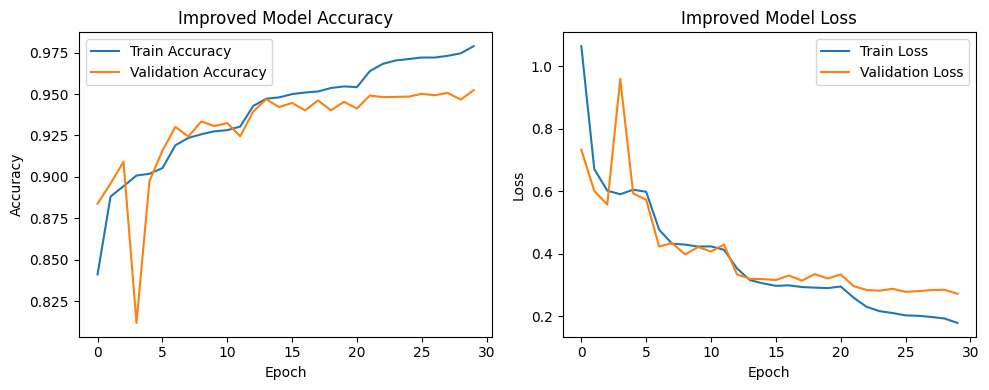

In [8]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n🔥 Improved Test Accuracy: {test_acc * 100:.2f}%")

# Save model and plot
model.save(f"{model_dir}/improved_cnn_model.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/improved_cnn_training_plot.png")
plt.show()
